In [6]:
import json
import os
import random
import re
import requests
import scrapy
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

from bs4 import BeautifulSoup
from furl import furl
from itemadapter import ItemAdapter
from itemloaders.processors import TakeFirst, Identity, Compose, MapCompose, Join
from lxml import html
from lxml.etree import tostring
from parsel import Selector
from scrapy.exceptions import DropItem
from scrapy.linkextractors import LinkExtractor
from scrapy.loader import ItemLoader
from scrapy.spiders import CrawlSpider, Rule
from selenium import webdriver
from selenium.common.exceptions import TimeoutException, NoSuchElementException
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.firefox.options import Options 
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from urllib.parse import urljoin

# Plus your own Scrapy items and itemloaders

In [38]:
questions_df = pd.read_csv("/Users/nicorrae/Desktop/Projects/BookScraper/questions.csv")
users_df = pd.read_csv("/Users/nicorrae/Desktop/Projects/BookScraper/users.csv")

### Part 2

In [36]:
def tag_analysis(tags_by, tag_list=None):
    
    if tag_list is None: ### ai
        tag_list = []

    #expand tags into individual rows
    #empty list to store expanded tag data
    #because each question can have multiple tags (comma separated) but we need to analyze
    #each tag individually, one row per tag
    tag_rows = []


    #loop through each question in the original dataframe
    for index, row in questions_df.iterrows():
        #get the tags string
        tags_string = row['tags']

        #split tby comma to get individual tags
        #tags are stored as comma separated strings, we need them as separate items
        individual_tags = tags_string.split(',')

        
        for tag in individual_tags:
            tag = tag.strip() #for whitespaces around names
    
            if tag_list: #filter by tag_list if specified, can be left empty and not, but used to analyse certain tags of interest
                if tag not in tag_list:
                    continue #skip the tag and move on next iteration
            #if we reach here, the tag passed the filter (or no filter was applied)
            #add this tag's data to our list for analysis
            #we need to preserve the answers/votes data for each tag occurrence for later calculations
            tag_rows.append({
                'tags': tag,
                'answers': row['answers'], #copy the questions answer count
                'votes': row['votes'] #copy the questions vote count
            })

    #convert the list of dictionaries back into a dataframe so its easier to use pandas
    tags_expanded = pd.DataFrame(tag_rows)

    ###calculate matrics based on tags_by parameter
    
    if tags_by == 'frequency': #count how many times each tag appears, we want to know which tags are most/least common
        tag_counts = {} 

        
        for tag in tags_expanded['tags']: #add 1 to the count if we've seen it before
            if tag in tag_counts:
                tag_counts[tag] = tag_counts[tag] + 1
            else:
                tag_counts[tag] = 1 #first time seeing this tag, start couunting at 1


        #convert dictionaries to pandas series for better(easier) sorting/plotting
        #series has built in sort methods and works with seaborn
        data = pd.Series(tag_counts)
        data = data.sort_values(ascending = False) #highest counts first
        #set labels for the plot
        ylabel = "Number of Questions"
        title = "Question Frequency by Tag"

    ## option 2 sum total answers for each tag across all questions
    #some tags may have fewer questions but more total engagement
    elif tags_by == "total_answers":
        tag_totals = {}

        for index, row in tags_expanded.iterrows():
            tag = row['tags']
            answers = row['answers']

            #add this question's answer to the tag's running total
            if tag in tag_totals:
                tag_totals[tag] = tag_totals[tag] + answers
            else:
                tag_totals[tag] = answers #first question with this tag, start the toal
            
        data = pd.Series(tag_totals)
        data = data.sort_values(ascending = False)

        ylabel = "Total Answers"
        title = "Total Answers by Tag"

    #calculate avg votes
    elif tags_by == "avg_votes":
        #calculate avg votes per question for each tag
        #shows which tags get the most community engagement per question
        #not only total, but average , for different question counts

        #first collect all vote values for each tag
        #we need all values to calc an avg 
        tag_votes = {}
        for index, row in tags_expanded.iterrows():
            tag = row['tags']
            votes = row['votes']
        #add this vote count to the tag's list of votes
            if tag in tag_votes:
                tag_votes[tag].append(votes)
            else:
                #first question with this tag, start a new list
                tag_votes[tag] = [votes]


        #now calculate the average for each tag
        #average = sum of all votes / number of questions
        tag_averages = {}
        for tag, votes_list in tag_votes.items(): #manual average calculations, sum divided by count
            avg = sum(votes_list) / len(votes_list)
            tag_averages[tag] = avg

        #convert to series and sort by highest average first
        data = pd.Series(tag_averages)
        data = data.sort_values(ascending = False)

        ylabel = "Average Votes"
        title = "Average Votes by Tag"
    #deal with invalid input
    else:
        #if tags_by isn't one of the three valid options, raise error
        #better to fail than have wrong results
        raise ValueError("tags_by must be frequency, total_answers or avg_votes")


    ### if specific tags were not chosen, code automatically picks the 'interesting (top)' ones
    #if we have all tags on there, it'll be hard to compare the useful ones
    #top 5 and bottom 5 is a good comparison of extremes
    if not tag_list:
        top_5_tags = data.head(5) #highest 5
        bottom_5_tags = data.tail(5) #lowest 5

        #combine them into one series for plotting
        #we want both on the same chart
        data = pd.concat([top_5_tags, bottom_5_tags])

    #visualising it
    plt.figure(figsize = (10, 6))
    sns.barplot(x = data.values, y=data.index, palette = "viridis")

    plt.xlabel(ylabel)
    plt.ylabel("Tags")
    plt.title(title)

    plt.tight_layout()
    plt.show()
        
        

/var/folders/17/8669m8f57cd5g8bd5dj2vrd80000gn/T/ipykernel_18486/3888716949.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data.values, y=data.index, palette = "viridis")


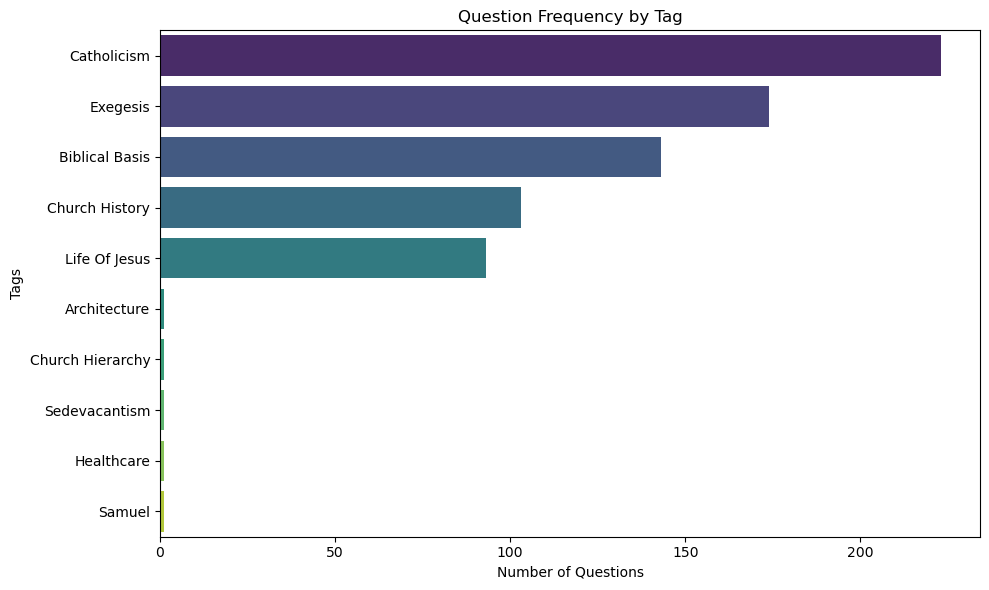

/var/folders/17/8669m8f57cd5g8bd5dj2vrd80000gn/T/ipykernel_18486/3888716949.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data.values, y=data.index, palette = "viridis")


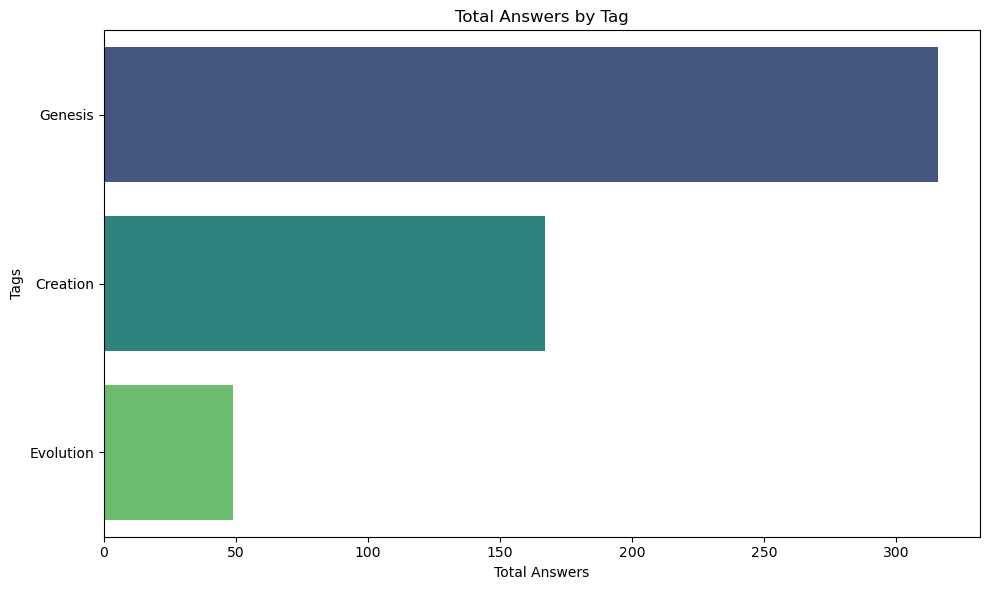

/var/folders/17/8669m8f57cd5g8bd5dj2vrd80000gn/T/ipykernel_18486/3888716949.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data.values, y=data.index, palette = "viridis")


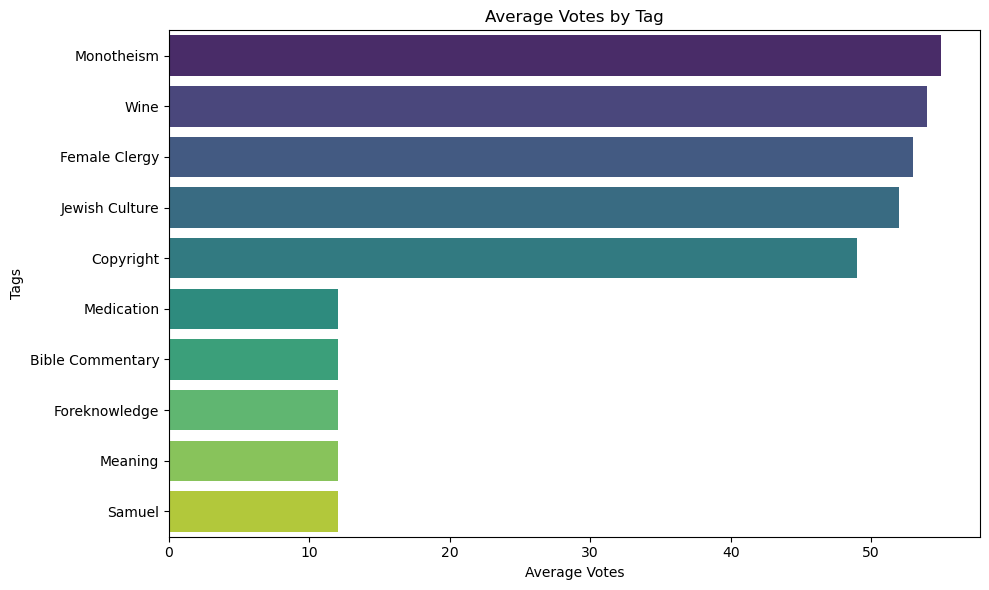

In [37]:
tag_analysis('frequency')

tag_analysis('total_answers', tag_list = ["Genesis", "Creation", "Evolution"])

tag_analysis('avg_votes')

### Part 3

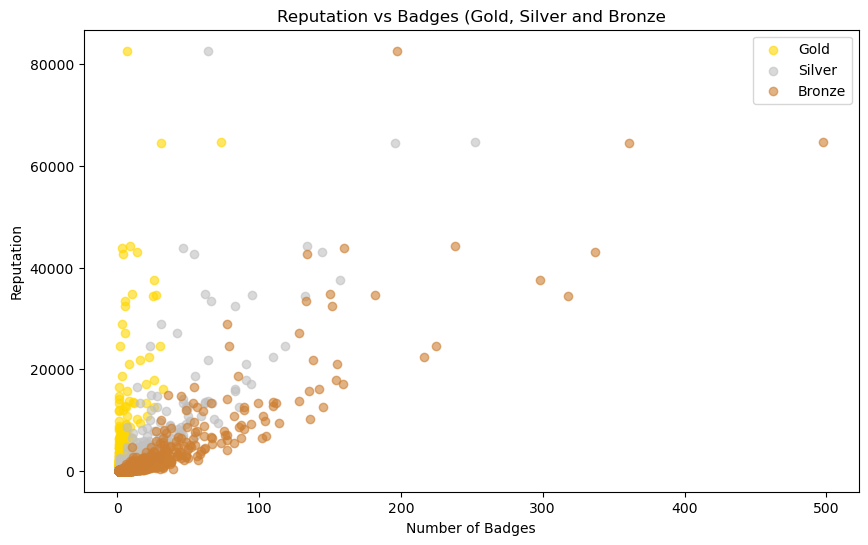

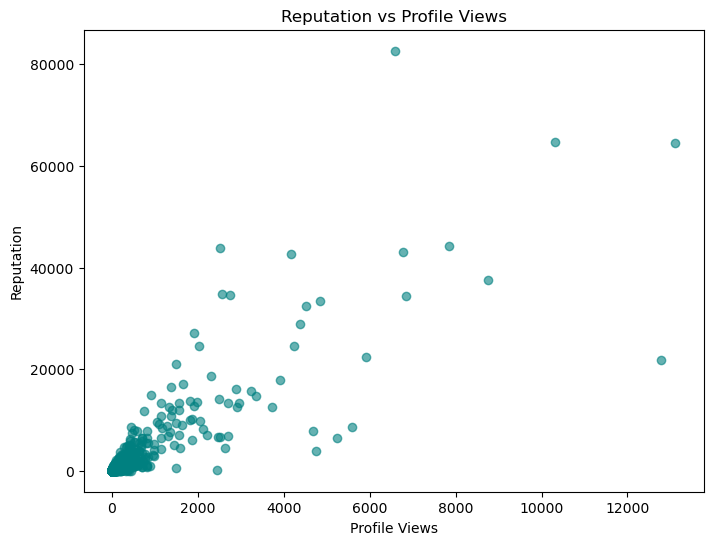

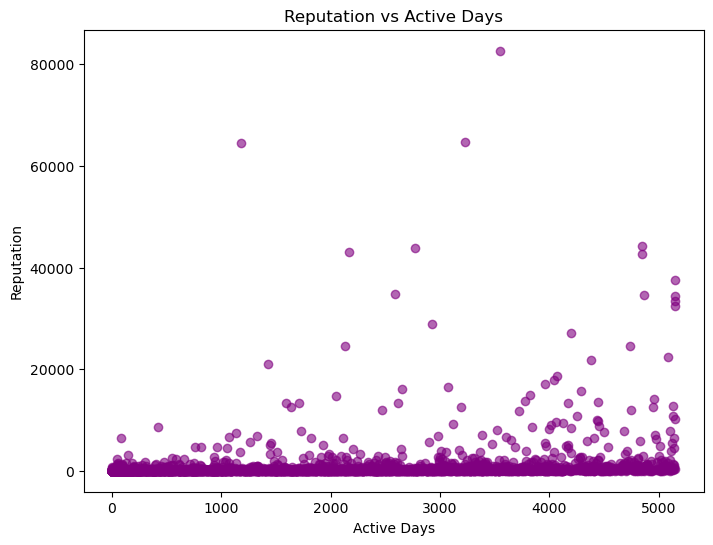

In [41]:
## Plot 1 Reputation vs Badges
plt.figure(figsize = (10, 6))
plt.scatter(users_df['gold'], users_df['reputation'], color = 'gold', alpha = 0.6, label = 'Gold')
plt.scatter(users_df['silver'], users_df['reputation'], color = 'silver', alpha = 0.6, label = 'Silver')
plt.scatter(users_df['bronze'], users_df['reputation'], color = '#CD7F32', alpha = 0.6, label = 'Bronze')

plt.xlabel("Number of Badges")
plt.ylabel("Reputation")
plt.title("Reputation vs Badges (Gold, Silver and Bronze")
plt.legend()
plt.show()

## Plot 2 Reputaiton vs Profile Views
plt.figure(figsize = (8,6))
plt.scatter(users_df["profile_views"], users_df["reputation"], color = "teal", alpha = 0.6)
plt.xlabel("Profile Views")
plt.ylabel("Reputation")
plt.title("Reputation vs Profile Views")

## Plot 3 Reputation vs Active Days
plt.figure(figsize=(8, 6))
plt.scatter(users_df["active_days"], users_df["reputation"], color = "purple", alpha = 0.6)
plt.xlabel("Active Days")
plt.ylabel("Reputation")
plt.title("Reputation vs Active Days")
plt.show()

Gold badges show the strongest positive correlation with reputation. Users with more gold badgest tend to have higher reputation, almost linearly. Silver badges have a moderate positive correlation, while bronze badges ar ethe weakest but still trend positively.

Profile views also show a positive correlation, though the considerate variance, some users with any views have low reputation and vice versa. Active days show little to no correlation with reputaiton, most users cluster at lower active days, and reputation does not increase simply with time on the site. Overall, the graphs tell us that high-value badges are the clearest indicator of repuation, whereas time spent or sheer volume of low-level badges is less informative.